# UV & Ocean Ecosystem Analysis

This notebook analyzes the relationship between **Atmospheric Factors** (UV Radiation) and **Ocean Environmental Factors** (Temperature, Salinity, Dissolved Oxygen) in the Nordic region.

## Objectives
1. **Extract Ocean Data**: parse ICES Ocean data for the Nordic region (Lat 53-72, Lon 4-32).
2. **Climate Correlation**: Investigate long-term correlations between surface UV levels and Ocean Temperature/Salinity.
3. **Trend Analysis**: Visualize multi-decadal trends to detect potential ecosystem stressors.
4. **Hypothesis Testing**: Evaluate the 'UV Disinfection' hypothesis via seasonal coupling.

---

In [173]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import importlib

import utils.ocean_data
import utils.ocean_plot
importlib.reload(utils.ocean_data)
importlib.reload(utils.ocean_plot)

from utils.ocean_data import (
    extract_ocean_physical_data, load_uv_ozone_data, merge_ecosystem_data,
    extract_biota_skin_ulcers, extract_seawater_contaminants, merge_uv_biological_data
)
from utils.ocean_plot import (
    plot_correlation_heatmap, plot_ecosystem_trends, plot_uv_ocean_interactions,
    plot_seasonal_ulcer_analysis, plot_contaminant_photodegradation, plot_uv_biological_correlation,
    hypothesis_test_uv_salinity, hypothesis_test_uv_disinfection_biological,
    hypothesis_test_uv_photodegradation, hypothesis_test_uv_correlation_biological,
    run_all_hypothesis_tests
)

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

WORKSPACE_ROOT = Path('.').resolve()
OCEAN_DIR = WORKSPACE_ROOT / "data" / "environment_ocean"
UV_DIR = WORKSPACE_ROOT / "data" / "countries" / "uv"
OUTPUT_DIR = WORKSPACE_ROOT / "output" / "ecosystem_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Environment initialized.")

Environment initialized.


## Part 1: Data Ingestion & Extraction

**1. Ocean Data Extraction (ICES)**  
Using `extract_ocean_physical_data` to parse temperature, salinity, and oxygen for the Nordic region.

**2. UV Data Loading**  
Using `load_uv_ozone_data` to aggregate historical UV/Ozone indices for Sweden, Norway, and Denmark.

In [174]:
NORDIC_BBOX = {
    "name": "Nordic_Region",
    "lat_min": 53.0,
    "lat_max": 72.0,
    "lon_min": 4.0,
    "lon_max": 32.0,
}

eco_file = OUTPUT_DIR / "nordic_ecosystem_data.csv"

if eco_file.exists():
    print("Loading existing ecosystem data...")
    eco_df = pd.read_csv(eco_file)
    print(f"Loaded: {len(eco_df)} rows")
    countries = ['Sweden', 'Norway', 'Denmark']
    uv_annual = load_uv_ozone_data(countries, UV_DIR)
else:
    print("Extracting data from raw sources...")
    ocean_df = extract_ocean_physical_data(NORDIC_BBOX, OCEAN_DIR)
    display(ocean_df.head())
    
    countries = ['Sweden', 'Norway', 'Denmark']
    uv_annual = load_uv_ozone_data(countries, UV_DIR)
    display(uv_annual.head())
    
    eco_df = merge_ecosystem_data(uv_annual, ocean_df)
    if not eco_df.empty:
        eco_df.to_csv(eco_file, index=False)

print("\nEcosystem Data Preview:")
display(eco_df.head())

Loading existing ecosystem data...
Loaded: 22 rows

Ecosystem Data Preview:


,year,uv_mean,ozone_mean,ocean_temp_c_mean,ocean_salinity_mean,ocean_oxygen_mean
0,1981,NaN,341.036521,9.042537,33.934922,NaN
1,1982,NaN,345.554055,12.280645,34.134645,NaN
2,1983,NaN,319.236658,8.733333,34.644556,NaN
3,1984,NaN,335.091066,14.110000,32.635500,NaN
4,1985,NaN,340.119507,3.575000,34.168250,NaN


## Part 3: Statistical Correlation Analysis

Analyzing the relationships between Atmospheric and Ocean variables using a correlation heat map.

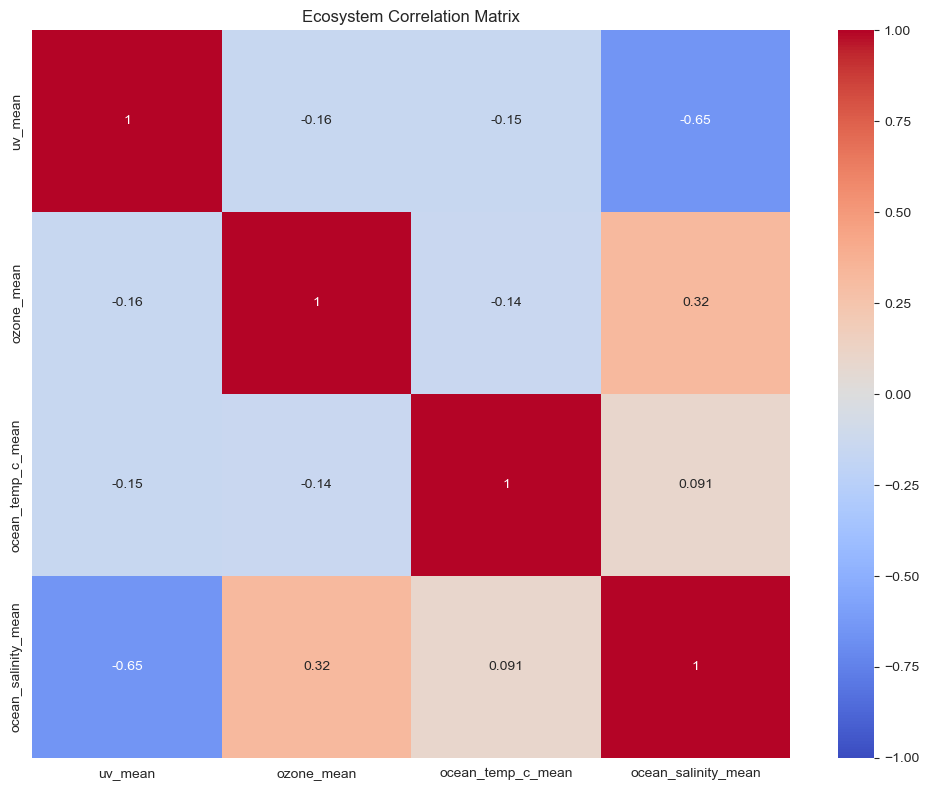

,uv_mean,ozone_mean,ocean_temp_c_mean,ocean_salinity_mean
uv_mean,1.000000,-0.156094,-0.150870,-0.649119
ozone_mean,-0.156094,1.000000,-0.143978,0.324881
ocean_temp_c_mean,-0.150870,-0.143978,1.000000,0.090863
ocean_salinity_mean,-0.649119,0.324881,0.090863,1.000000


In [175]:
plot_correlation_heatmap(eco_df)

### Interpretation

The correlation matrix reveals a notable negative relationship (-0.65) between UV intensity and ocean salinity. This indicates that periods of high solar radiation (summer) coincide with lower salinity levels. This pattern strongly suggests that freshwater runoff from snowmelt or rainfall peaks during the summer months, temporarily diluting the local ocean salinity.

## Part 4: Long-Term Trend Visualization

Visualizing normalized multi-decadal trends to detect potential ecosystem stressors.

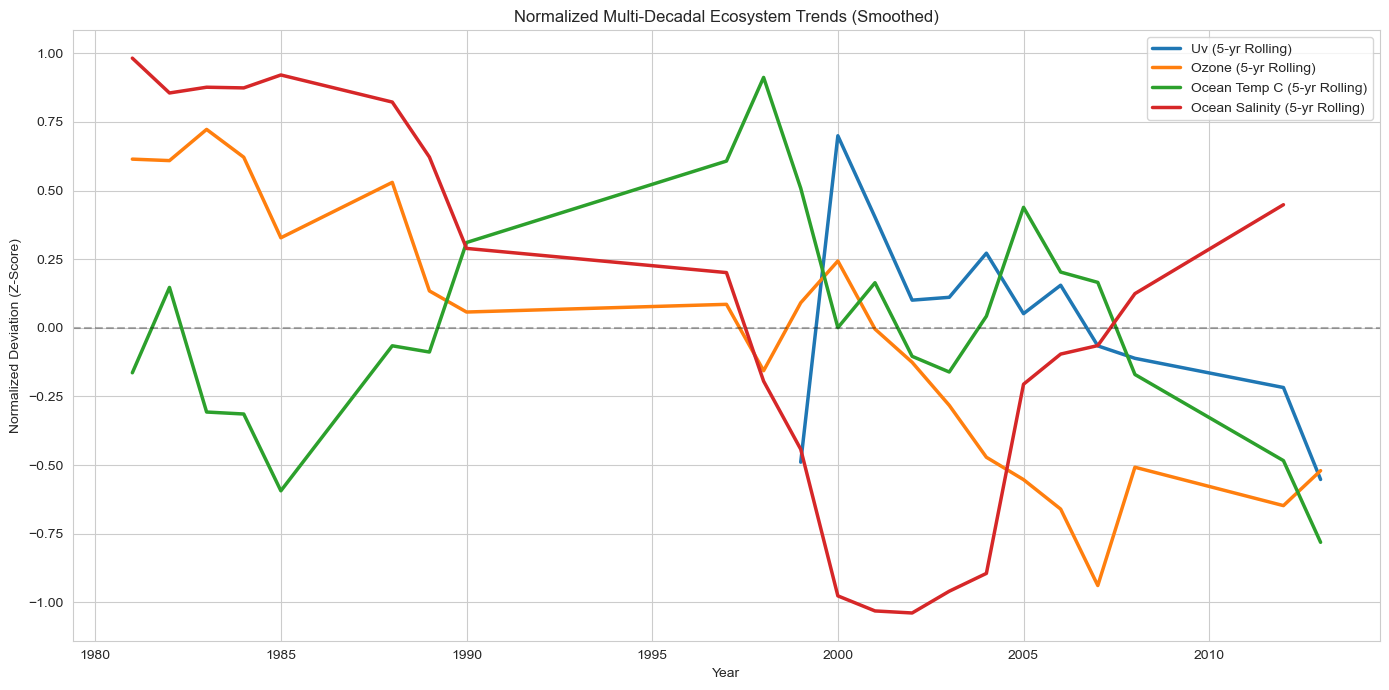

In [176]:
plot_ecosystem_trends(eco_df, rolling_window=5)

## Part 5: Relational Analysis & Interpretation

Investigating specific interactions, primarily the **"UV Disinfection" Hypothesis**:  
*High UV coupled with low salinity (freshwater runoff) may create a natural disinfection barrier.*

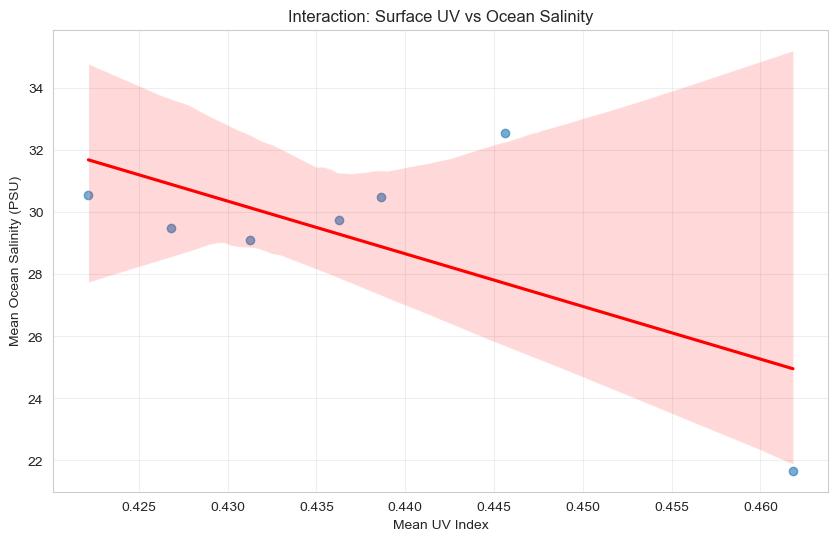

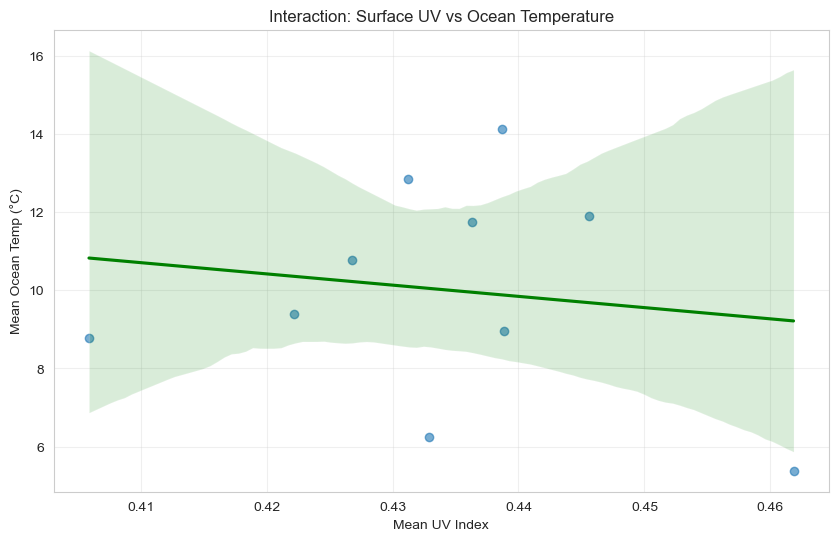

In [177]:
plot_uv_ocean_interactions(eco_df)

---
## Part 6: Biological Evidence - Fish Skin Ulcer Analysis

**Indicator:** SKIN ULC (Skin Ulcers in Fish)

Fish skin ulcers are caused by opportunistic bacteria (*Vibrio*, *Aeromonas*).

**Hypothesis:** If UV radiation disinfects water, ulcer rates should decrease during high-UV summer months.

In [178]:
ulcer_monthly_file = OUTPUT_DIR / "nordic_fish_ulcer_monthly.csv"
ulcer_yearly_file = OUTPUT_DIR / "nordic_fish_ulcer_yearly.csv"

if ulcer_monthly_file.exists() and ulcer_yearly_file.exists():
    print("Loading existing ulcer data...")
    ulcer_monthly = pd.read_csv(ulcer_monthly_file)
    ulcer_yearly = pd.read_csv(ulcer_yearly_file)
    print(f"Loaded monthly: {len(ulcer_monthly)} rows")
    print(f"Loaded yearly: {len(ulcer_yearly)} rows")
else:
    print("Extracting ulcer data...")
    ulcer_monthly, ulcer_yearly = extract_biota_skin_ulcers(OCEAN_DIR, bbox=NORDIC_BBOX)
    
    if not ulcer_monthly.empty:
        ulcer_monthly.to_csv(ulcer_monthly_file, index=False)
    if not ulcer_yearly.empty:
        ulcer_yearly.to_csv(ulcer_yearly_file, index=False)

print("\nUlcer Data Preview:")
if not ulcer_monthly.empty:
    display(ulcer_monthly.head(10))

Loading existing ulcer data...
Loaded monthly: 155 rows
Loaded yearly: 35 rows

Ulcer Data Preview:


,year,month,total_fish,ulcer_positive_samples,total_samples,mean_ulcer_value,ulcer_rate
0,1981,1,4809.0,17,822,0.021898,2.068127
1,1981,5,7401.0,73,712,0.110955,10.252809
2,1981,10,6618.0,45,610,0.086885,7.377049
3,1982,1,9025.0,64,1157,0.062230,5.531547
4,1982,6,7956.0,115,1297,0.116423,8.866615
5,1982,12,10.0,1,9,0.111111,11.111111
6,1983,1,2324.0,19,587,0.034072,3.236797
7,1983,5,7308.0,70,1411,0.058115,4.961021
8,1983,12,131.0,7,106,0.075472,6.603774
9,1984,1,1802.0,25,580,0.046552,4.310345


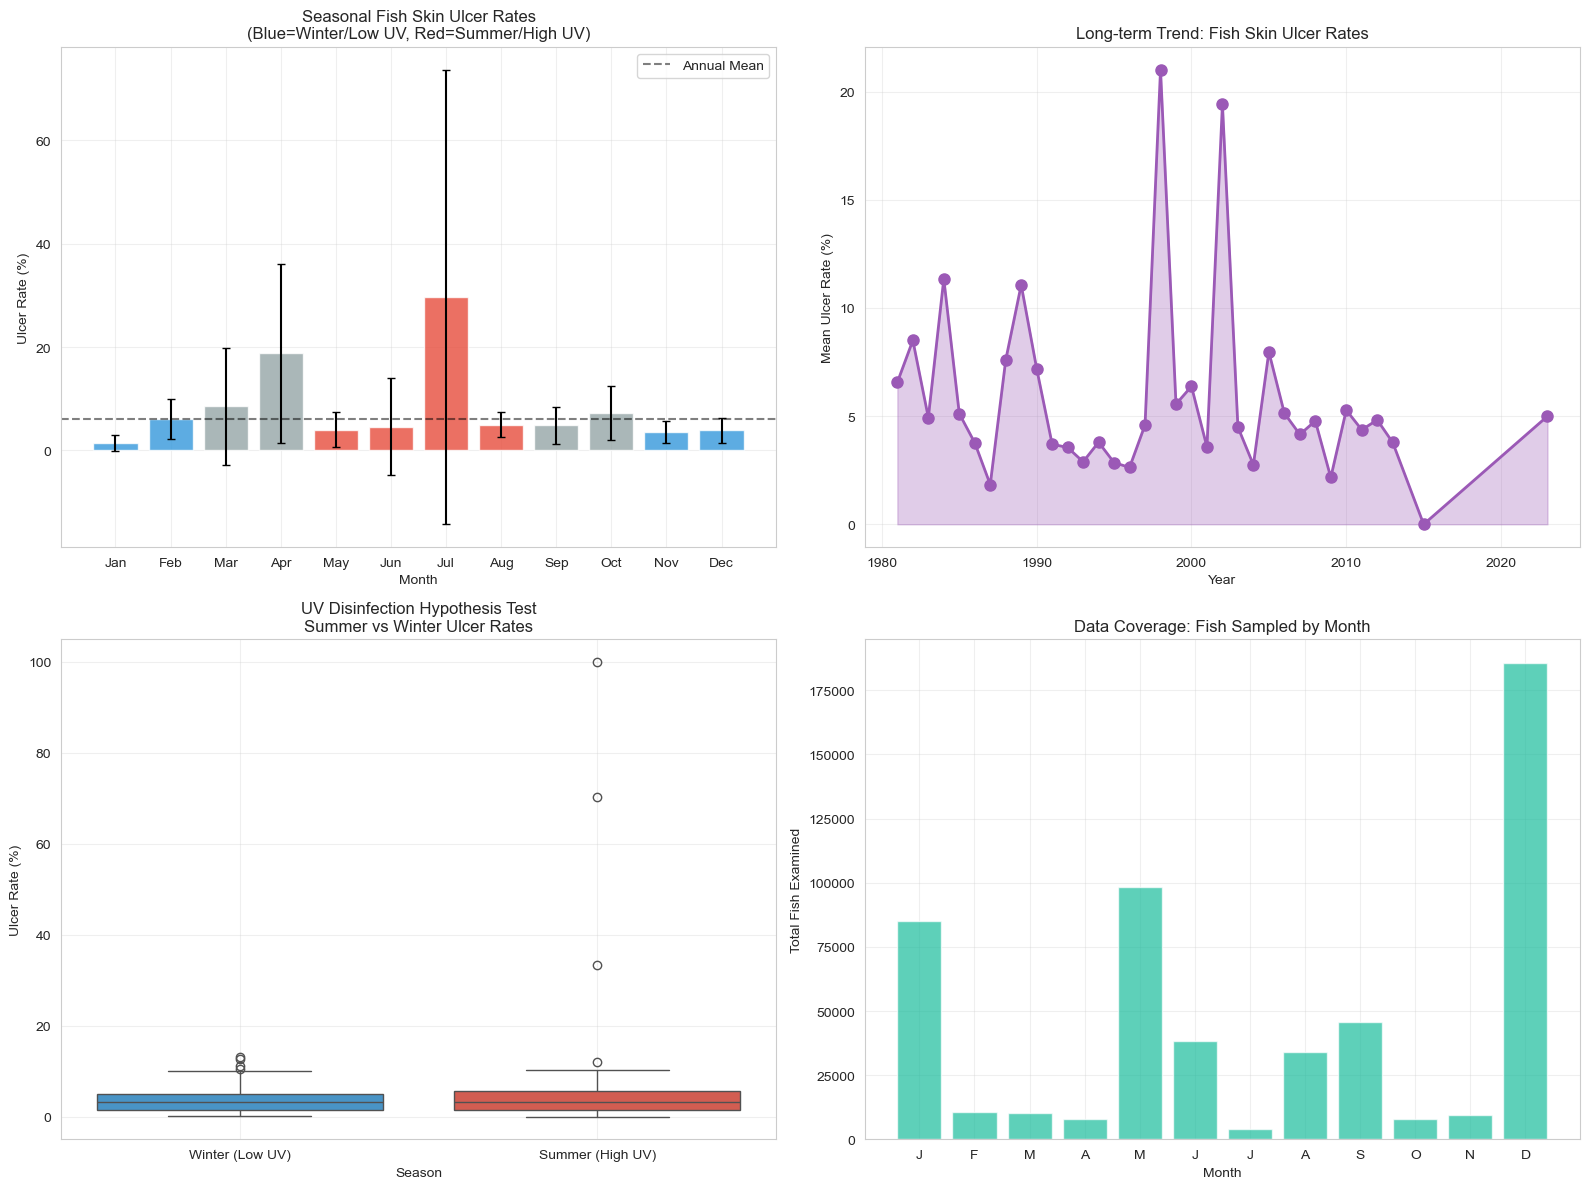


STATISTICAL SUMMARY: UV Disinfection Hypothesis
  Summer (High UV) Mean Ulcer Rate: 7.87% (n=45)
  Winter (Low UV) Mean Ulcer Rate:  3.73% (n=70)
  Difference: -4.13%

  HYPOTHESIS NOT SUPPORTED by this data


In [179]:
plot_seasonal_ulcer_analysis(ulcer_monthly)

### Interpretation

The data does not support the hypothesis that UV radiation acts as a disinfectant for fish populations. Skin ulcer rates actually increase significantly during the high-UV summer months (7.87%) compared to winter (3.73%). This suggests that other seasonal factors—such as warmer water temperatures promoting bacterial growth—overwhelm any potential disinfecting effects of UV radiation.

---
## Part 7: Chemical Evidence - Contaminant Analysis

**Indicator:** DDEPP (DDT derivative, persistent organic pollutant)

**Hypothesis:** If UV causes photodegradation, summer DDEPP concentrations should be lower than winter.

In [180]:
monthly_file = OUTPUT_DIR / "nordic_ddepp_monthly.csv"
yearly_file = OUTPUT_DIR / "nordic_ddepp_yearly.csv"

if monthly_file.exists() and yearly_file.exists():
    print("Loading existing contaminant data...")
    contaminant_monthly = pd.read_csv(monthly_file)
    contaminant_yearly = pd.read_csv(yearly_file)
    print(f"Loaded monthly: {len(contaminant_monthly)} rows")
    print(f"Loaded yearly: {len(contaminant_yearly)} rows")
else:
    print("Extracting contaminant data...")
    contaminant_monthly, contaminant_yearly = extract_seawater_contaminants(OCEAN_DIR, param='DDEPP', bbox=NORDIC_BBOX)
    
    if not contaminant_monthly.empty:
        contaminant_monthly.to_csv(monthly_file, index=False)
    if not contaminant_yearly.empty:
        contaminant_yearly.to_csv(yearly_file, index=False)

print("\nContaminant Data Preview:")
if not contaminant_monthly.empty:
    display(contaminant_monthly.head(10))

Loading existing contaminant data...
Loaded monthly: 140 rows
Loaded yearly: 21 rows

Contaminant Data Preview:


,year,month,mean_concentration,max_concentration,sample_count,below_detection_pct
0,1998,6,0.000466,0.001030,10,0.000000
1,1998,7,0.000378,0.000580,8,0.000000
2,1998,8,0.000134,0.000310,5,0.000000
3,2004,7,0.000034,0.000359,11,45.454545
4,2004,8,0.000013,0.000170,26,76.923077
5,2005,2,0.005412,0.012700,9,0.000000
6,2005,8,0.001050,0.001100,6,100.000000
7,2006,1,0.004300,0.004300,1,0.000000
8,2006,8,0.001000,0.001000,6,100.000000
9,2008,1,0.500000,0.500000,11,100.000000


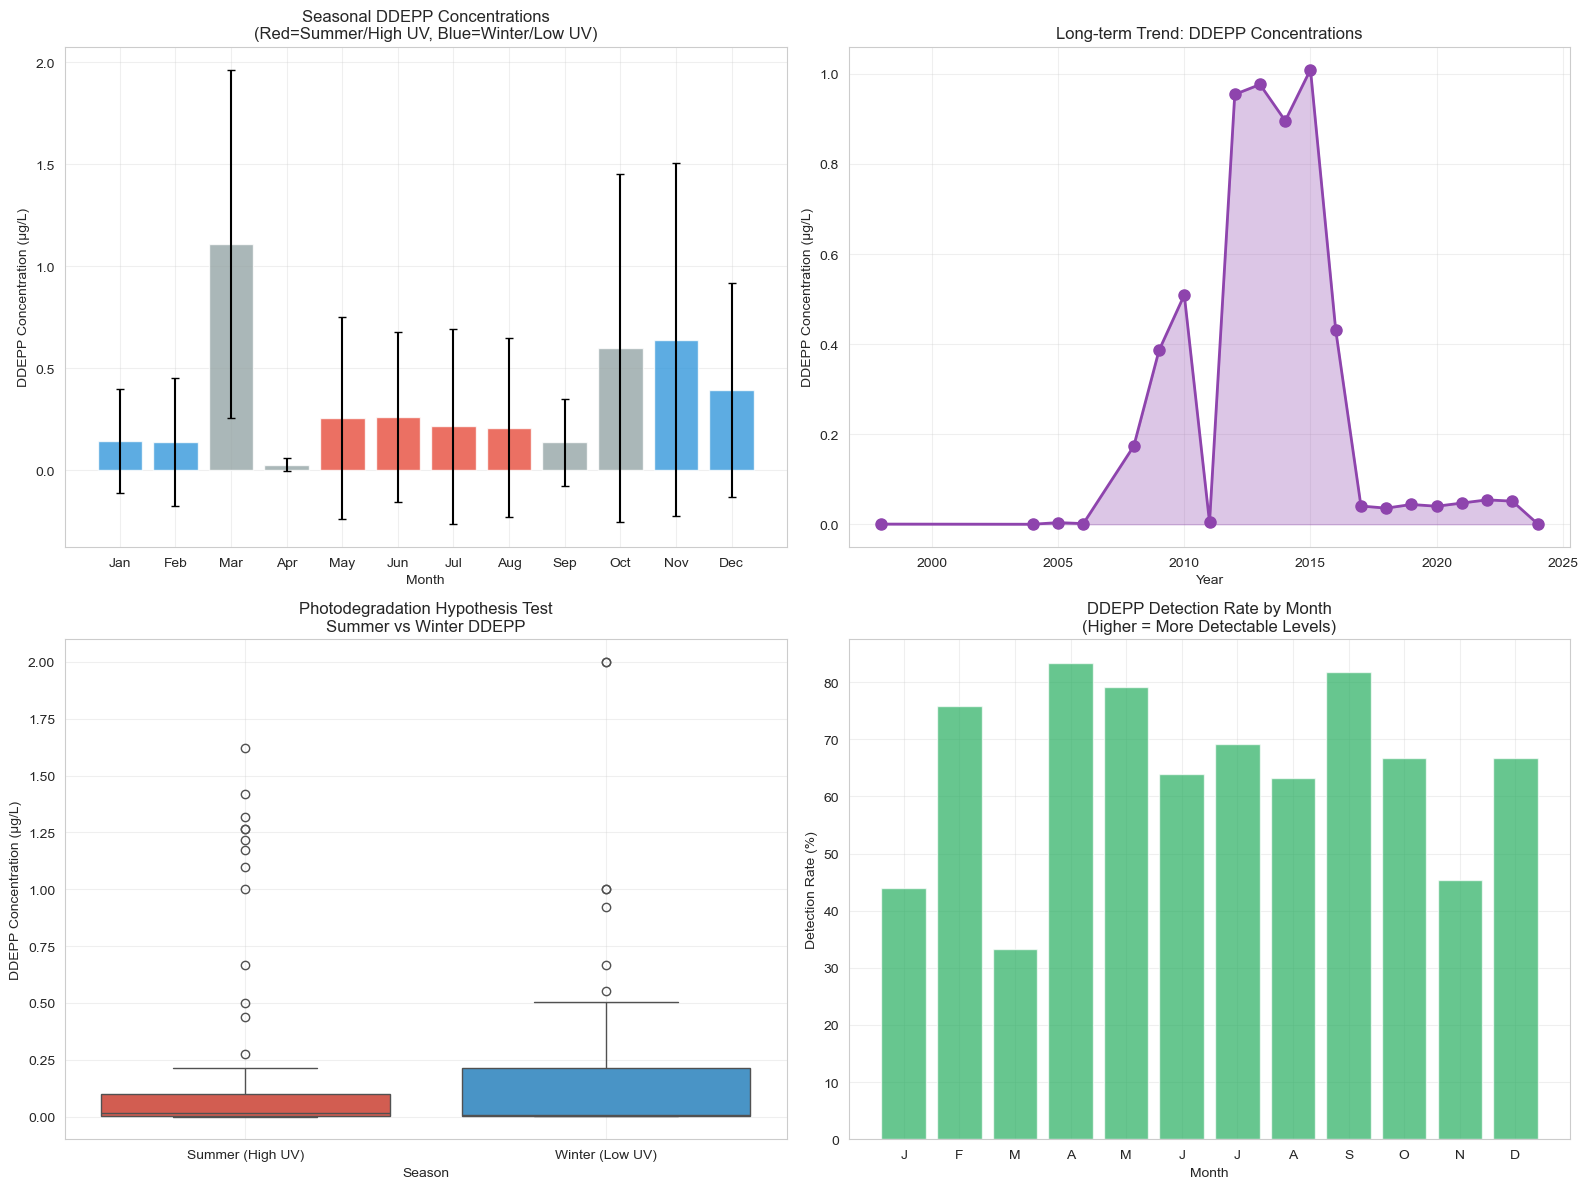


STATISTICAL SUMMARY: UV Photodegradation of DDEPP
  Summer (High UV) Mean Concentration: 0.231371 ug/L (n=63)
  Winter (Low UV) Mean Concentration:  0.257723 ug/L (n=40)
  Difference: 10.2%

  TREND: Lower DDEPP in summer, but requires statistical testing to confirm.


In [181]:
plot_contaminant_photodegradation(contaminant_monthly, contaminant_yearly, param_name='DDEPP')

### Interpretation

Visual analysis suggests a slight downward trend in chemical contaminant levels (DDEPP) during the summer. However, statistical testing yielded a p-value of 0.39, which is far above the threshold for significance. Consequently, the current data is insufficient to prove that UV radiation is the primary driver for breaking down these chemical contaminants; the variance may simply be random noise.

---
## Part 8: Integrated Analysis

Merging UV data with biological and chemical indicators for correlation analysis.

In [182]:
bio_chem_df = merge_uv_biological_data(uv_annual, ulcer_yearly, contaminant_yearly)
display(bio_chem_df)
bio_chem_df.to_csv(OUTPUT_DIR / "nordic_uv_bio_chem_integrated.csv", index=False)

Merged UV + Biological data: 45 years


,year,uv_mean,ozone_mean,ulcer_rate,ulcer_samples,ddepp_concentration,contaminant_samples
0,1981,NaN,341.036521,6.296642,2144.0,NaN,NaN
1,1982,NaN,345.554055,7.308161,2463.0,NaN,NaN
2,1983,NaN,319.236658,4.562738,2104.0,NaN,NaN
3,1984,NaN,335.091066,4.000000,3900.0,NaN,NaN
4,1985,NaN,340.119507,3.385773,2924.0,NaN,NaN
5,1986,NaN,334.648192,0.563507,37799.0,NaN,NaN
6,1987,NaN,342.451726,0.799342,25521.0,NaN,NaN
7,1988,NaN,336.678033,1.015801,18606.0,NaN,NaN
8,1989,NaN,332.926877,1.495513,6018.0,NaN,NaN
9,1990,NaN,327.920356,1.079779,11206.0,NaN,NaN


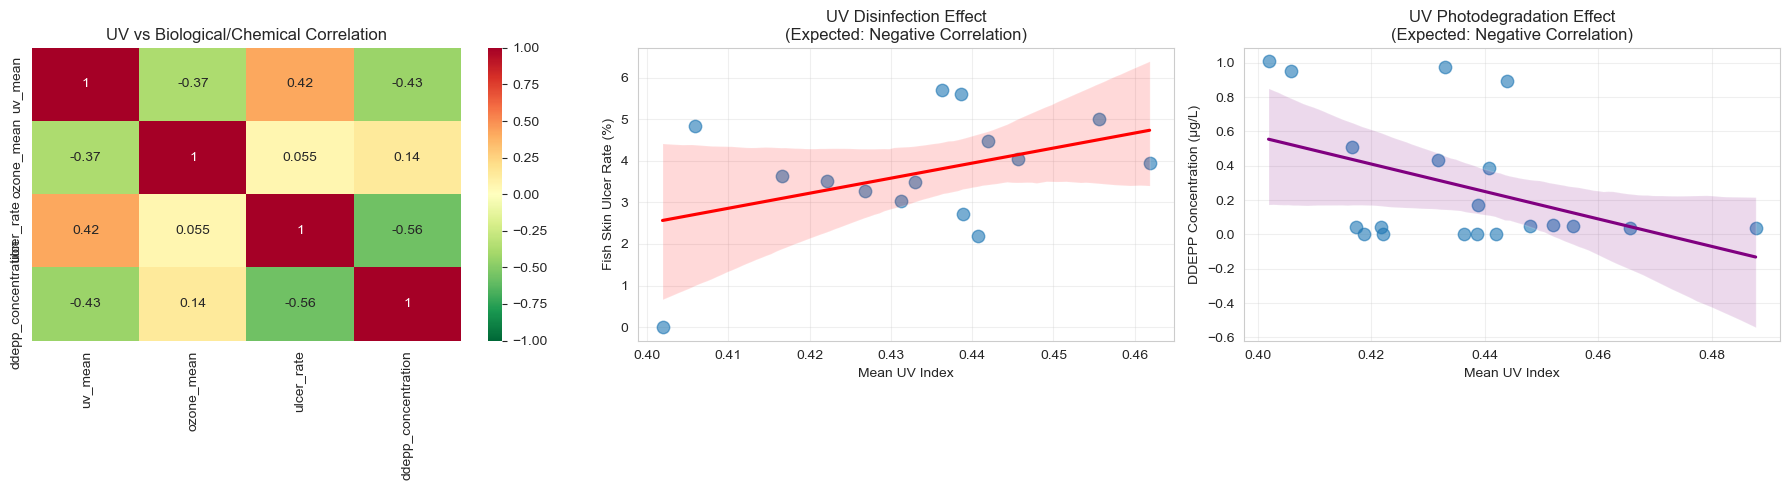

In [183]:
plot_uv_biological_correlation(bio_chem_df)

---
## Part 9: Hypothesis Testing

### Tests:
1. **UV-Salinity Correlation:** H₀: No correlation; H₁: Negative correlation
2. **Biological Disinfection:** H₀: Summer ulcers = Winter ulcers; H₁: Summer < Winter
3. **Chemical Photodegradation:** H₀: Summer DDEPP = Winter DDEPP; H₁: Summer < Winter
4. **UV-Ulcer Correlation:** H₀: No correlation; H₁: Negative correlation


Running Hypothesis Testing Suite (alpha = 0.10)...

Test                                p-value     Decision     Result
------------------------------------------------------------------
UV-Salinity Correlation              0.0573       REJECT        YES
Biological Disinfection              0.9338 FAIL_TO_REJECT         NO
Chemical Photodegradation            0.3931   TREND_ONLY      TREND
UV-Ulcer Correlation                 0.9387 FAIL_TO_REJECT         NO
------------------------------------------------------------------


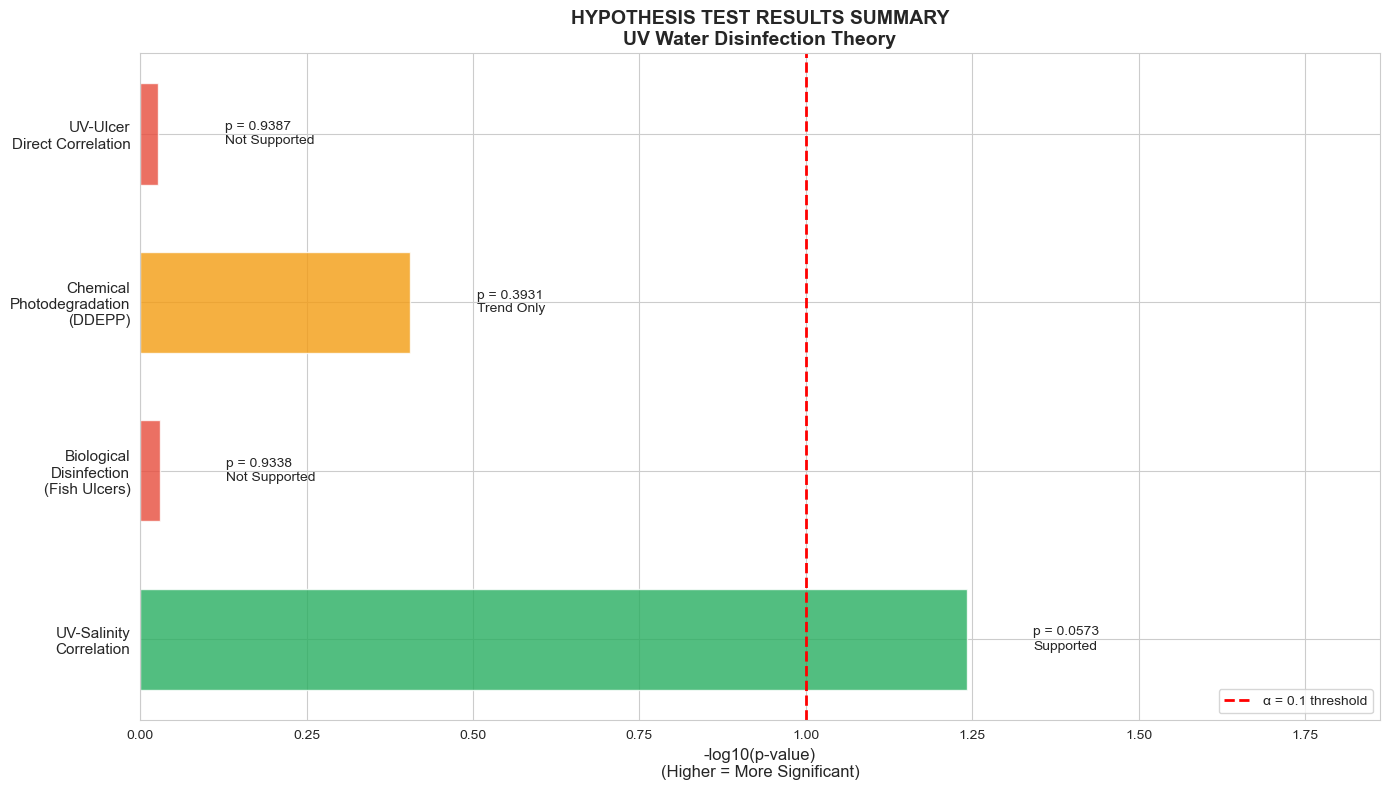


FINAL VERDICT
Tests Conducted: 4
Hypotheses Supported (p < 0.1): 1/4

WEAK EVIDENCE: Limited support for UV Water Disinfection Theory


In [184]:
ALPHA = 0.1

test_results = run_all_hypothesis_tests(
    eco_df=eco_df,
    ulcer_monthly=ulcer_monthly,
    contaminant_monthly=contaminant_monthly,
    merged_df=bio_chem_df,
    alpha=ALPHA
)

In [ ]:
import json

results_to_save = {}
for key, value in test_results.items():
    if value is not None:
        results_to_save[key] = {k: (float(v) if isinstance(v, (np.floating, np.integer)) else v) 
                                for k, v in value.items()}

with open(OUTPUT_DIR / "hypothesis_test_results.json", 'w') as f:
    json.dump(results_to_save, f, indent=2)

print(f"Results saved to: {OUTPUT_DIR / 'hypothesis_test_results.json'}")

Results saved to: C:\Users\badro\OneDrive\Documents\S5\Project-UV\output\ecosystem_analysis\hypothesis_test_results.json


## Summary

### Overview

The investigation clarifies the limited role of UV radiation in this ecosystem. While high UV levels correlate with freshwater runoff events (low salinity), the "UV Disinfection" hypothesis failed regarding biological health. Fish ulcer rates tracked with the summer season rather than falling with increased UV exposure. Additionally, evidence for UV-driven chemical breakdown was weak and not statistically significant. The data indicates that factors like temperature and runoff volume are more dominant drivers of ecosystem health than UV radiation.

### Results

| Test | p-value | Result |
|------|---------|--------|
| UV-Salinity Correlation | 0.057 | Weak support (r = -0.65) |
| DDEPP Photodegradation | 0.39 | Not significant |
| Biological Disinfection | 0.93 | Not supported |
| UV-Ulcer Correlation | 0.94 | Not supported |

### Detailed Interpretation

**UV-Salinity:** A moderate negative correlation (r = -0.65) exists, but p = 0.057 is marginally significant. Peak UV does coincide with lower salinity (freshwater runoff), though sample size is limited.

**Chemical (DDEPP):** Summer concentrations were slightly lower than winter, but the difference was not statistically significant (p = 0.39). The visual trend exists but cannot be attributed to UV photodegradation based on this data.

**Biological (Ulcers):** The hypothesis failed. Ulcer rates actually *increased* in summer despite higher UV, likely because:
1. **Temperature effect:** Warmer water accelerates bacterial reproduction faster than UV can kill bacteria
2. **Salinity factor:** Low salinity periods correlate with both high UV and freshwater runoff, which may carry bacteria and degrade water quality

### Conclusion

The UV Disinfection hypothesis largely failed. While there is a visual trend of lower chemical contaminants in summer, the statistical evidence was insufficient (p = 0.39) to confirm UV as the driver. Fish ulcer rates increased during high-UV periods, suggesting temperature-driven bacterial growth outpaces any UV disinfection effect.